# **Explore entities by category 🔎**

This notebook allows exploration annotated entities.

## **Load libraries and setup**


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

In [2]:
%load_ext watermark
%watermark

Last updated: 2026-04-21T17:17:55.487541+02:00

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 8.13.2

Compiler    : Clang 22.1.1 
OS          : Darwin
Release     : 24.0.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit



## **Load data**


In [3]:
entities_path = Path("../data/entities.tsv")

In [4]:
entities_df = pd.read_csv(entities_path, sep="\t")
entities_df

,entity,category,json_file
0,popc,MOL,zenodo_34415.json
1,amber,FFM,zenodo_34415.json
2,lipid14,FFM,zenodo_34415.json
3,cacl2,MOL,zenodo_34415.json
4,popc,MOL,zenodo_34415.json
...,...,...,...
1814,peggo,MOL,figshare_11894358.json
1815,peg,MOL,figshare_11894358.json
1816,dox,MOL,figshare_11894358.json
1817,dox,MOL,figshare_11894358.json


In [5]:
# Aggregate by 'entity' and 'category' to separate entities like 'charmm'
# that could be both FFM and SOFTNAME.
entities_by_category = (entities_df
 .groupby(["entity", "category"])
 .agg(
     occurrence=("entity", "count"),
     json_files=("json_file", ",".join),
     number_of_files=("json_file", "nunique")
 )
  .reset_index()
)
entities_by_category

,entity,category,occurrence,json_files,number_of_files
0,(gvpgv)7,MOL,1,figshare_5532214.json,1
1,0.5 μs,STIME,1,zenodo_4106413.json,1
2,1 microsecond,STIME,6,"zenodo_1488094.json,zenodo_4012224.json,figsha...",6
3,1 ns,STIME,1,figshare_8046437.json,1
4,1 μs,STIME,1,figshare_5546158.json,1
...,...,...,...,...,...
687,α-amylase,MOL,2,"figshare_20376757.json,figshare_20376757.json",1
688,α-conotoxin lsia,MOL,2,"zenodo_3908769.json,zenodo_3908769.json",1
689,α3β2 nachr,MOL,2,"zenodo_3908769.json,zenodo_3908769.json",1
690,α‑amylase,MOL,1,figshare_20376757.json,1


In [6]:
# Aggregate by category
entities_agg = (entities_by_category
 .groupby("category")
 .agg(
     total_entities=("occurrence", "sum"),
     unique_entities=("entity", "nunique")
 )
 .sort_values(by="total_entities", ascending=False)
)
entities_agg.loc["total"] = entities_agg.sum(numeric_only=True)
entities_agg

,total_entities,unique_entities
category,,
MOL,1132,422
FFM,246,86
SOFTNAME,169,40
STIME,116,62
TEMP,98,42
SOFTVERS,58,40
total,1819,692


In [7]:
def list_entities(df: pd.DataFrame, category: str) -> pd.DataFrame:
    """List entities for a given category, sorted by occurrence.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: 'entity', 'occurrence', 'json_files', 'number_of_files'.
    """
    return (df
     .query("category == @category")
     .sort_values("occurrence", ascending=False)
     .reset_index(drop=True)
    )


def make_wordcloud(df: pd.DataFrame, category: str) -> None:
    """Make a word cloud for a given category."""
    df_tmp = list_entities(df, category)
    freq = dict(zip(df_tmp["entity"], df_tmp["number_of_files"], strict=False))
    wc = WordCloud(background_color="white", max_words=150)
    wc.generate_from_frequencies(freq)
    # show
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

## Molecules 🧬


In [8]:
list_entities(entities_by_category, "MOL")

,entity,category,occurrence,json_files,number_of_files
0,popc,MOL,64,"zenodo_34415.json,zenodo_34415.json,zenodo_344...",26
1,dppc,MOL,36,"zenodo_1009027.json,zenodo_1009027.json,zenodo...",11
2,nacl,MOL,33,"zenodo_1009027.json,zenodo_1009027.json,zenodo...",16
3,cholesterol,MOL,25,"zenodo_2653735.json,zenodo_2653735.json,zenodo...",10
4,meth,MOL,18,"figshare_11704443.json,figshare_11704443.json,...",1
...,...,...,...,...,...
417,g-domain,MOL,1,figshare_13135976.json,1
418,g protein,MOL,1,zenodo_5226209.json,1
419,fungal cellobiohydrolase,MOL,1,zenodo_2537734.json,1
420,fullerene,MOL,1,figshare_5051593.json,1


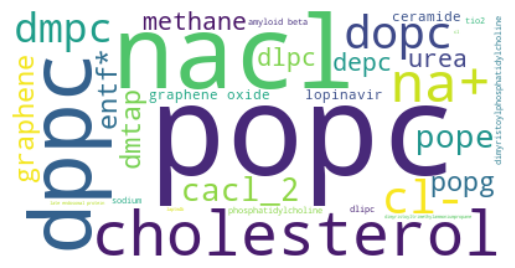

In [9]:
make_wordcloud(entities_by_category, "MOL")

## Force Field Model Name 🛠️


In [10]:
list_entities(entities_by_category, "FFM")

,entity,category,occurrence,json_files,number_of_files
0,charmm36,FFM,41,"zenodo_1009027.json,zenodo_1009027.json,zenodo...",21
1,tip3p,FFM,21,"zenodo_34415.json,zenodo_1167532.json,zenodo_1...",20
2,charmm,FFM,14,"zenodo_1198158.json,zenodo_1198158.json,zenodo...",7
3,gaff,FFM,8,"zenodo_6755131.json,figshare_14766557.json,fig...",4
4,slipids,FFM,8,"zenodo_1293813.json,zenodo_1293813.json,zenodo...",4
...,...,...,...,...,...
81,generalized amber force field,FFM,1,figshare_14766557.json,1
82,gromos 54a7,FFM,1,figshare_8046437.json,1
83,gromos 56a6carbo/carbo_r,FFM,1,figshare_7607222.json,1
84,gromos54a7,FFM,1,figshare_4806544.json,1


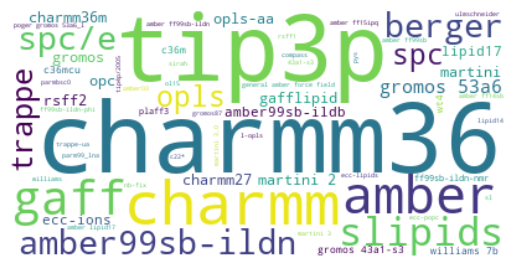

In [11]:
make_wordcloud(entities_by_category, "FFM")

## Software name ⚙️


In [12]:
list_entities(entities_by_category, "SOFTNAME")

,entity,category,occurrence,json_files,number_of_files
0,gromacs,SOFTNAME,87,"zenodo_34415.json,zenodo_1009027.json,zenodo_1...",58
1,charmm-gui,SOFTNAME,11,"zenodo_2653735.json,zenodo_838635.json,zenodo_...",11
2,vmd,SOFTNAME,7,"zenodo_5060102.json,zenodo_7007107.json,zenodo...",4
3,plumed,SOFTNAME,6,"zenodo_838635.json,zenodo_838635.json,zenodo_3...",3
4,namd,SOFTNAME,4,"figshare_14498668.json,zenodo_3696970.json,zen...",3
5,modeller,SOFTNAME,4,"zenodo_6970327.json,zenodo_6970327.json,zenodo...",2
6,mdanalysis,SOFTNAME,4,"figshare_8046437.json,figshare_8046437.json,ze...",3
7,ani2x,SOFTNAME,3,"zenodo_5060102.json,zenodo_5060102.json,zenodo...",1
8,moe,SOFTNAME,3,"zenodo_3988469.json,zenodo_3988469.json,zenodo...",1
9,colabfold,SOFTNAME,3,"zenodo_6970327.json,zenodo_6970327.json,zenodo...",1


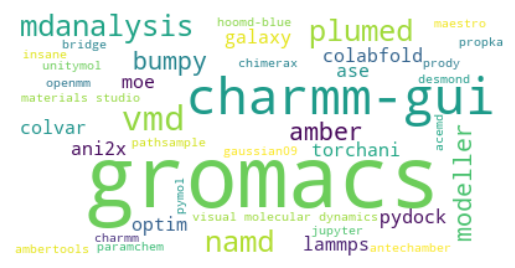

In [13]:
make_wordcloud(entities_by_category, "SOFTNAME")

## Software version 🔢


In [14]:
list_entities(entities_by_category, "SOFTVERS")

,entity,category,occurrence,json_files,number_of_files
0,4.5,SOFTVERS,7,"zenodo_13853.json,zenodo_13853.json,zenodo_155...",4
1,4.0.7,SOFTVERS,3,"zenodo_1293762.json,zenodo_14591.json,zenodo_1...",2
2,5.1.4,SOFTVERS,3,"zenodo_1198158.json,zenodo_1118682.json,zenodo...",3
3,v. 5.1,SOFTVERS,2,"zenodo_1198158.json,zenodo_1198454.json",2
4,19,SOFTVERS,2,"zenodo_3786821.json,zenodo_3786821.json",1
5,3.x,SOFTVERS,2,"zenodo_51750.json,zenodo_53212.json",2
6,2021.4,SOFTVERS,2,"zenodo_7323535.json,zenodo_7323535.json",1
7,2020.4,SOFTVERS,2,"zenodo_7007107.json,figshare_22182562.json",2
8,5.0.3,SOFTVERS,2,"zenodo_34415.json,zenodo_30904.json",2
9,2016.3,SOFTVERS,2,"zenodo_1167532.json,zenodo_1167532.json",1


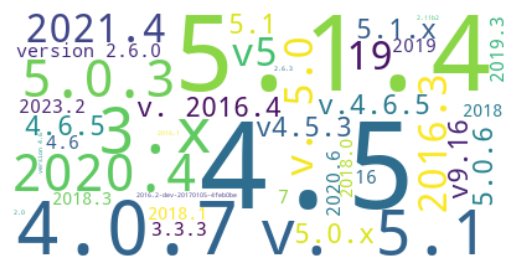

In [15]:
make_wordcloud(entities_by_category, "SOFTVERS")

## Simulation time ⏱


In [16]:
list_entities(entities_by_category, "STIME")

,entity,category,occurrence,json_files,number_of_files
0,500ns,STIME,12,"zenodo_1009027.json,zenodo_1009027.json,zenodo...",2
1,500 ns,STIME,8,"zenodo_7007107.json,zenodo_7007107.json,zenodo...",7
2,200 ns,STIME,8,"zenodo_1167532.json,figshare_4806544.json,zeno...",6
3,100 ns,STIME,6,"zenodo_6755131.json,zenodo_247386.json,zenodo_...",6
4,1 microsecond,STIME,6,"zenodo_1488094.json,zenodo_4012224.json,figsha...",6
...,...,...,...,...,...
57,250 ns,STIME,1,zenodo_7007107.json,1
58,27ns,STIME,1,zenodo_3908769.json,1
59,3 μs,STIME,1,zenodo_7007107.json,1
60,300 nanoseconds,STIME,1,zenodo_5153261.json,1


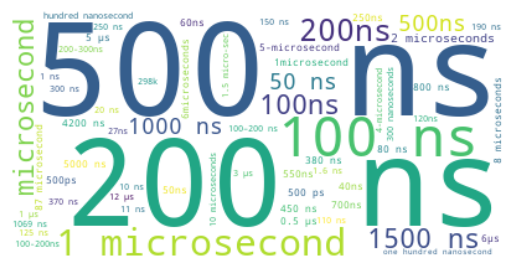

In [17]:
make_wordcloud(entities_by_category, "STIME")

## Temperature 🌡️


In [18]:
list_entities(entities_by_category, "TEMP")

,entity,category,occurrence,json_files,number_of_files
0,310k,TEMP,13,"figshare_8046437.json,zenodo_1219494.json,zeno...",7
1,310 k,TEMP,13,"zenodo_1219494.json,zenodo_1293813.json,zenodo...",11
2,300 k,TEMP,9,"figshare_4806544.json,zenodo_6349893.json,zeno...",7
3,298 k,TEMP,7,"zenodo_1167532.json,zenodo_838635.json,zenodo_...",6
4,325k,TEMP,5,"zenodo_1009027.json,zenodo_1009027.json,zenodo...",2
5,303k,TEMP,4,"zenodo_13853.json,zenodo_247386.json,zenodo_10...",4
6,313 k,TEMP,3,"zenodo_1118682.json,zenodo_1293762.json,zenodo...",2
7,363 k,TEMP,2,"zenodo_7007107.json,zenodo_7007107.json",1
8,323 k,TEMP,2,"zenodo_51750.json,zenodo_53212.json",2
9,320k,TEMP,2,"zenodo_1009027.json,zenodo_1009027.json",1


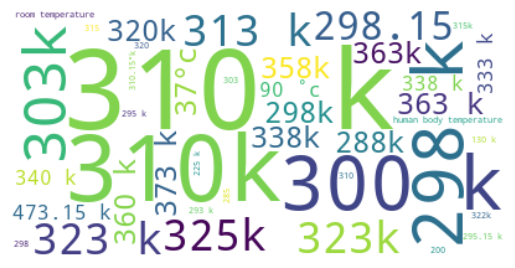

In [19]:
make_wordcloud(entities_by_category, "TEMP")